# MobileNet-V3-Large Iteration 01 — Full Backbone + L1 + Patient Metadata Fusion + TTA

## Objective
First MobileNet experiment. MobileNetV3-Large is a lightweight but capable architecture (~3M params) that uses inverted residuals with squeeze-and-excitation blocks. This iteration establishes a strong baseline by fully unfreezing the backbone, applying L1 regularisation (λ=1e-3), fusing patient metadata (age, sex, body localisation), and evaluating with 8× TTA — the same configuration that achieved Test F2 0.6952 on EfficientNet-B0 (Iter 06).

## Architecture

| Component | EfficientNet-B0 Iter 05/06 (reference) | MobileNetV3-Large Iter 01 |
|---|---|---|
| Model | `EfficientNetB0WithMetadata` | **`MobileNetV3LargeWithMetadata`** |
| Image features | 1280-dim (B0 features + avgpool) | **960-dim (MV3-L features + avgpool)** |
| Patient metadata | age + sex + localization (dim=17) | age + sex + localization (dim=17) |
| Metadata encoder | Linear(17, 32) → ReLU | Linear(17, 32) → ReLU |
| Fusion | cat(1280, 32) → Dropout → Linear(1312, 1) | **cat(960, 32) → Dropout → Linear(992, 1)** |
| Unfrozen | Last 6 blocks of features | **Full backbone (all 16 blocks)** |
| Trainable params | ~4M | **~3M** |
| Dropout | 0.5 | 0.5 |
| L1 lambda | 1e-3 | 1e-3 |
| pos_weight | ~8.1 | ~8.1 |
| LR — backbone | 1e-4 | **1e-4** |
| LR — head | 1e-3 | 1e-3 |
| Weight decay | 1e-3 | 1e-3 |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Epochs | 30 | 30 |
| TTA at inference | Yes (8×) | Yes (8×) |

## Hypothesis
MobileNetV3-Large is designed for efficiency with competitive accuracy. Its SE blocks and hard-swish activations should provide strong feature representations for dermoscopic images. With full unfreezing and metadata fusion matching the best EfficientNet configuration, this model may achieve comparable or higher AUC-ROC despite fewer parameters, and should beat the benchmark Test F2 of 0.6879.

## Import libraries, set seed, and choose device

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from sklearn.metrics import fbeta_score

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.mobilenet import MobileNetV3LargeWithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.utils import seed_everything, seed_worker

import pandas as pd

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Positive weight: tensor([8.1117], device='cuda:0')
Train: 7991 | Val: 2024 | Test: 1511


## Model Definition

In [3]:
METADATA_DIM = 17
DROPOUT      = 0.5

model = MobileNetV3LargeWithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=False,
    dropout=DROPOUT,
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.features.parameters(),      'lr': 1e-4},
    {'params': model.avgpool.parameters(),        'lr': 1e-4},
    {'params': model.meta_encoder.parameters(),  'lr': 1e-3},
    {'params': model.head.parameters(),          'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 1e-3

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 2,973,521 / 2,973,521
L1 lambda: 0.001 | L2 lambda: 0.001 | Dropout: 0.5


## Training Loop

In [4]:
best_val_auc = 0.0
best_epoch   = 0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device, use_metadata=True)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), ROOT / 'models/01.mobilenet_v3_metadata_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

print(f'Best checkpoint: epoch {best_epoch} | Val AUC: {best_val_auc:.4f}')

Epoch [1/30]
  Train | Loss: 0.9326, Bal Acc: 0.7199, Recall: 0.7560, F2: 0.5163, AUC: 0.8048
  Val   | Loss: 0.8172, Bal Acc: 0.7608, Recall: 0.8941, F2: 0.5794, AUC: 0.8676
  -> Saved best model (val AUC: 0.8676)


Epoch [2/30]
  Train | Loss: 0.7943, Bal Acc: 0.7778, Recall: 0.8347, F2: 0.5880, AUC: 0.8662
  Val   | Loss: 0.7724, Bal Acc: 0.7753, Recall: 0.8941, F2: 0.5964, AUC: 0.8773
  -> Saved best model (val AUC: 0.8773)


Epoch [3/30]
  Train | Loss: 0.7302, Bal Acc: 0.8160, Recall: 0.8643, F2: 0.6404, AUC: 0.8922
  Val   | Loss: 0.7749, Bal Acc: 0.7751, Recall: 0.8220, F2: 0.5973, AUC: 0.8793
  -> Saved best model (val AUC: 0.8793)


Epoch [4/30]
  Train | Loss: 0.7235, Bal Acc: 0.8094, Recall: 0.8415, F2: 0.6328, AUC: 0.8927
  Val   | Loss: 0.7609, Bal Acc: 0.7953, Recall: 0.8602, F2: 0.6231, AUC: 0.8920
  -> Saved best model (val AUC: 0.8920)


Epoch [5/30]
  Train | Loss: 0.6881, Bal Acc: 0.8207, Recall: 0.8506, F2: 0.6496, AUC: 0.9048
  Val   | Loss: 0.8078, Bal Acc: 0.7917, Recall: 0.8093, F2: 0.6205, AUC: 0.8847


...

Epoch [26/30]
  Train | Loss: 0.4601, Bal Acc: 0.8905, Recall: 0.9213, F2: 0.7603, AUC: 0.9572
  Val   | Loss: 0.8637, Bal Acc: 0.8150, Recall: 0.7542, F2: 0.6622, AUC: 0.9134


Epoch [27/30]
  Train | Loss: 0.4639, Bal Acc: 0.8908, Recall: 0.9190, F2: 0.7615, AUC: 0.9561
  Val   | Loss: 0.8469, Bal Acc: 0.8204, Recall: 0.7712, F2: 0.6696, AUC: 0.9150


Epoch [28/30]
  Train | Loss: 0.4557, Bal Acc: 0.8930, Recall: 0.9213, F2: 0.7654, AUC: 0.9578
  Val   | Loss: 0.8626, Bal Acc: 0.8232, Recall: 0.7712, F2: 0.6746, AUC: 0.9143


Epoch [29/30]
  Train | Loss: 0.4480, Bal Acc: 0.8988, Recall: 0.9350, F2: 0.7729, AUC: 0.9588
  Val   | Loss: 0.8580, Bal Acc: 0.8202, Recall: 0.7712, F2: 0.6691, AUC: 0.9143


Epoch [30/30]
  Train | Loss: 0.4695, Bal Acc: 0.8897, Recall: 0.9111, F2: 0.7618, AUC: 0.9556
  Val   | Loss: 0.8522, Bal Acc: 0.8214, Recall: 0.7754, F2: 0.6708, AUC: 0.9147
Best checkpoint: epoch 16 | Val AUC: 0.9188


## Plot Train and Validation Curves

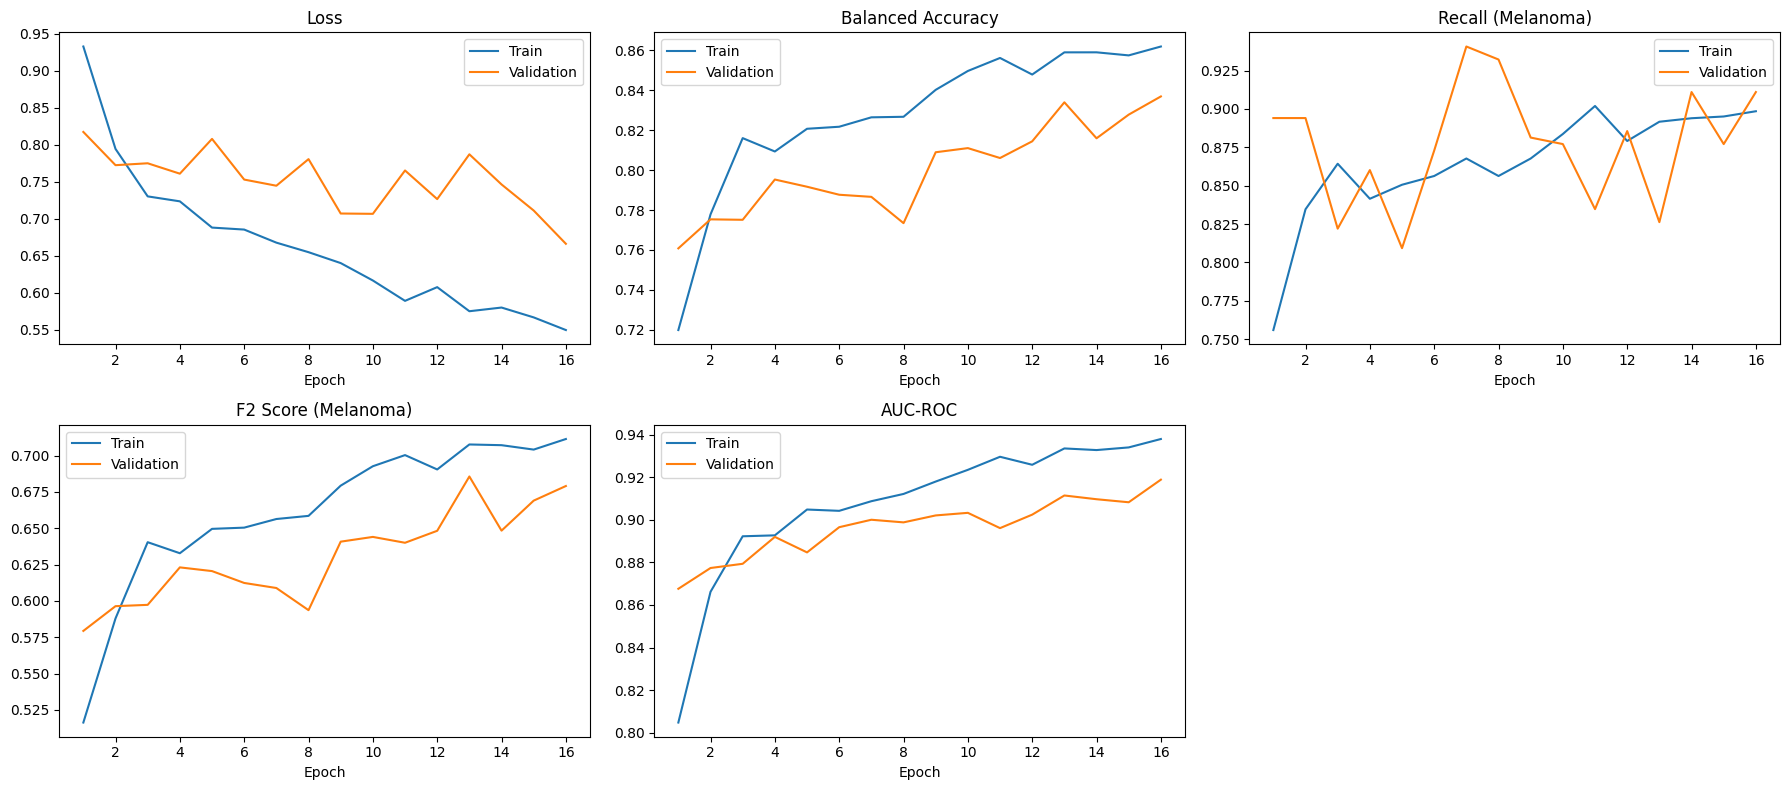

In [5]:
plot_training_curves(train_history, val_history, best_epoch=best_epoch)

## Threshold Tuning (Best Val F2)

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

model.load_state_dict(torch.load(str(ROOT / 'models/01.mobilenet_v3_metadata_best.pth'), map_location=device))
model.eval()

val_dataset_raw = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=None,
)

def _base(extra=None):
    ops = [transforms.Resize((224, 224))]
    if extra:
        ops += extra
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)

tta_transforms = [
    _base(),                                                                      # 1. identity
    _base([transforms.RandomHorizontalFlip(p=1.0)]),                              # 2. H-flip
    _base([transforms.RandomVerticalFlip(p=1.0)]),                                # 3. V-flip
    _base([transforms.RandomHorizontalFlip(p=1.0),
           transforms.RandomVerticalFlip(p=1.0)]),                                # 4. HV-flip
    _base([transforms.RandomRotation(degrees=(90, 90))]),                         # 5. rotate 90
    _base([transforms.RandomRotation(degrees=(180, 180))]),                       # 6. rotate 180
    _base([transforms.RandomRotation(degrees=(270, 270))]),                       # 7. rotate 270
    _base([transforms.ColorJitter(brightness=0.1, contrast=0.1)]),                # 8. color jitter
]


def tta_predict(model, dataset, device, tta_transforms):
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            pil_img, metadata, label = dataset[idx]
            metadata = metadata.unsqueeze(0).to(device)

            preds = []
            for t in tta_transforms:
                tensor = t(pil_img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor, metadata)).item()
                preds.append(prob)

            all_probs.append(np.mean(preds))
            all_labels.append(label)

    return np.array(all_probs), np.array(all_labels)


print('Running TTA on validation set...')
val_probs, val_labels = tta_predict(model, val_dataset_raw, device, tta_transforms)

thresholds = np.arange(0.01, 0.90, 0.01)
f2_scores  = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0)
              for t in thresholds]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Running TTA on validation set...
Best threshold: 0.54 | Val F2: 0.6802


## Test Set Evaluation

In [7]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

test_dataset_raw = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=None,
)

print('Running TTA on test set...')
test_probs, test_labels = tta_predict(model, test_dataset_raw, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f'Threshold:          {best_threshold:.2f}')
print(f'AUC-ROC:            {auc:.4f}')
print(f'Balanced Accuracy:  {bal_acc:.4f}')
print(f'F2 Score:           {f2:.4f}')
print()
print(classification_report(test_labels, all_preds, target_names=['Non-Melanoma', 'Melanoma'], digits=4))

Running TTA on test set...
Threshold:          0.54
AUC-ROC:            0.9114
Balanced Accuracy:  0.8162
F2 Score:           0.6492

              precision    recall  f1-score   support

Non-Melanoma     0.9751    0.7903    0.8730      1340
    Melanoma     0.3388    0.8421    0.4832       171

    accuracy                         0.7962      1511
   macro avg     0.6570    0.8162    0.6781      1511
weighted avg     0.9031    0.7962    0.8289      1511

